# Introduction
---

## Background

This project builds on [Galaxy image deconvolution for weak gravitational lensing with unrolled plug-and-play ADMM](https://doi.org/10.1093/mnrasl/slad032) [1] to improve shear estimation for weak gravitational lensing analysis. Precise shear estimation is crucial for studying dark matter distribution and cosmic structure, but it is challenging due to optical and atmospheric blurring. To address this, the study focused on enhancing astronomical image deconvolution. The proposed Unrolled Plug-and-Play ADMM deconvolution method significantly improved galaxy shape measurements, reducing shear ellipticity error by up to 45% across varying signal-to-noise ratios. This deep learning approach outperformed existing deconvolution techniques, providing a more accurate tool for reconstructing complex galaxy images and advancing research on cosmic structure and evolution.

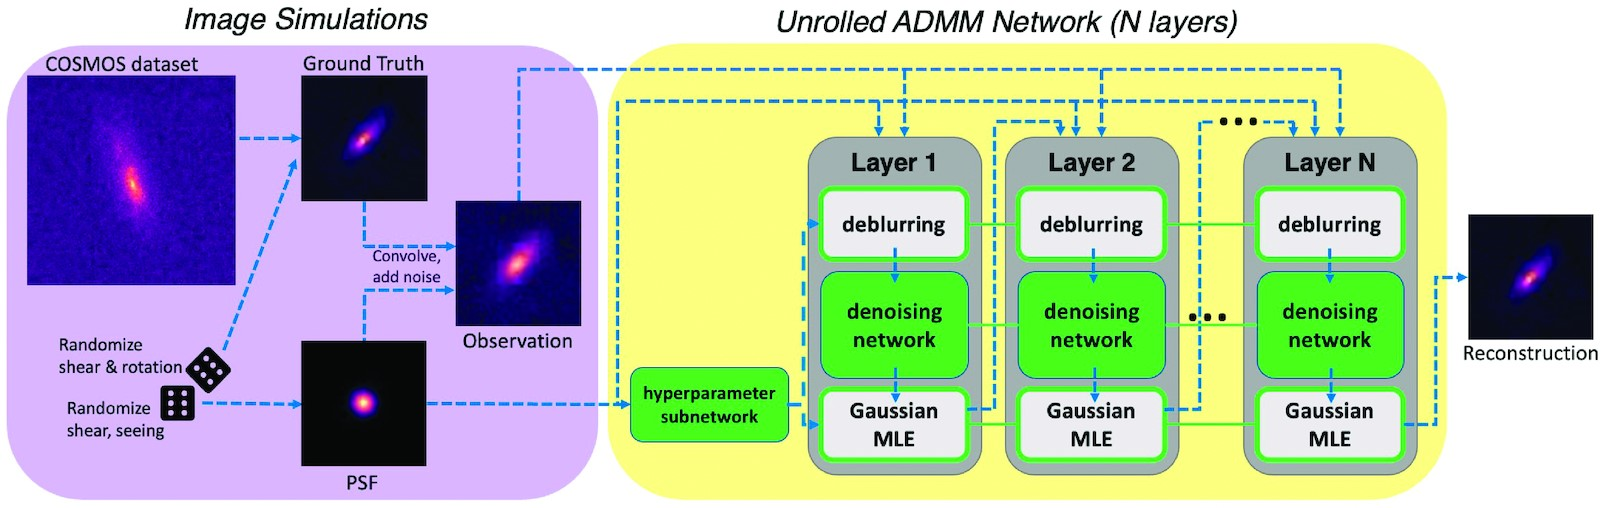
Image credit [1].

Unrolled Plug-and-Play ADMM Neural Network:

- Unrolled [ADMM](https://mdav.ece.gatech.edu/ece-6270-spring2021/notes/19-admm.pdf): Predictable compute time with fixed number of iterations (i.e., no convergence criteria)
- Trainable [Plug-and-Play Denoisers](https://doi-org.turing.library.northwestern.edu/10.1109/TCI.2016.2629286): Trainable ResUNet architecures
- Hyperparameter Estimation Network: Optimize deblurring and Gaussian hyperparameters for SNR and PSF variations
- Multi-Scale L1 Loss: Minimize pixel-wise loss at multiple levels of detail
- Skip Connections: Mitigate gradient vanishing for stable training

Simulated Dataset:

- Raw images sourced from [COSMOS Real Galaxy Dataset](https://cosmos.astro.caltech.edu/) [2]
- Simulation toolkit: Galsim
- Target observation context: Upcoming Legacy Survey of Space and Time (LSST)
- Image Transformation:
    - Random shearing (uniform distribution: [0.01, 0.05])
    - Random rotation (uniform distribution: [0, 2π])
    - Simulated weak lensing effects
- Blurring Techniques:
- Atmospheric PSFs: Simulated using Kolmogorov function
    - Seeing (FWHM) sampled from specific distribution
    - Added shear and rotation to simulate atmospheric variation
- Optical PSFs: Simulated using Galsim
    - Used LSST telescope parameters
    - Incorporated diffraction, obscuration, defocus, coma aberration, and astigmatism
- Noise and Scaling:
    - Convolved with combined PSF
    - Brightness scaled to match Signal-to-Noise Ratio (SNR)
    - Added Gaussian noise (standard deviation: 19.4 ADUs)
    - Downsampled to LSST pixel scale (0.2 arcsec)

[Fourier Power Function Shapelets (FPFS)](https://fpfs.readthedocs.io/en/latest/index.html) [3] was the method used to estimate shear in all the experiments and served as the ground truth when comparing the shear values in the simulated ground truth images with the model's output. It works by decomposing galaxy images into shapelet basis functions in Fourier space, which allows for efficient measurement of the distortion caused by gravitational lensing. The FPFS approach has advantages over traditional real-space shapelets by being less sensitive to noise and better at handling PSF (Point Spread Function) corrections. It's particularly useful for measuring cosmic shear in large-scale structure surveys.

## Project

This project aims to improve shear estimation accuracy by training a deconvolution model with a loss function that prioritizes galaxy shape preservation over pixel-wise mean absolute error (MAE). This approach is inspired by physics-driven machine learning methods used to solve inverse problems for specific scientific objectives. If you’re interested in the broader context, please check out my [presentation](https://docs.google.com/presentation/d/1GzlFERBeAunb54iO4kMIUtRP6zpAzw7-KMLmTRG2sPQ/edit?usp=sharing).

## Experimental Setup

To ensure a fair comparison of different loss functions, all other model components and training conditions were kept constant:
- Model Architecture: Unrolled Plug-and-Play ADMM Neural Network
- Dataset: Same training and validation set as the motivating paper (40,000 training examples, validation set 40% of training size, varying SNR)
- Iterations: 2
- Optimizer: Adam
- Learning Rate: 1e-4
- Epochs: 10

Multi-Scale MAE serves as a baseline loss function for evaluating the performance of alternative loss functions.

# Imports/Globals
---

In [1]:
import os
import matplotlib.pyplot as plt
import torch
from models.unrolled_admm_gaussian import UnrolledADMMGaussian
from utils.fit_ellipse import transform_tensor_batched, mask_batched, mask_to_points_and_weights_batched, ellipse_params_batched, ellipse_fit_metric, ellipse_params_from_moments, visualize_shapelet_basis
from utils.utils_plotting import plot_multiscale_batch, plot_batched_images, plot_batched_points, plot_batch_with_ellipses, plot_inference_results

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# sample batch
example_batch_path = './example_batch/'
example_batch_idxs = [18162, 16975, 4001, 33649]

psf_batch = []
obs_batch = []
gt_batch = []
alpha_batch = []

for idx in example_batch_idxs:
    psf = torch.load(os.path.join(example_batch_path, f"psf_{idx}.pth")).unsqueeze(0)
    obs = torch.load(os.path.join(example_batch_path, f"obs_{idx}.pth")).unsqueeze(0)
    gt = torch.load(os.path.join(example_batch_path, f"gt_{idx}.pth")).unsqueeze(0)
    
    alpha = obs.ravel().mean().float().view(1, 1, 1, 1)
    
    psf_batch.append(psf)
    obs_batch.append(obs)
    gt_batch.append(gt)
    alpha_batch.append(alpha)
    
psf_batch = torch.cat(psf_batch, dim=0)  # Shape: [4, 1, 48, 48]
obs_batch = torch.cat(obs_batch, dim=0)  # Shape: [4, 1, 48, 48]
gt_batch = torch.cat(gt_batch, dim=0)    # Shape: [4, 1, 48, 48]
alpha_batch = torch.cat(alpha_batch, dim=0)  # Shape: [4, 1, 1, 1]

print(f"obs_batch shape: {obs_batch.shape}")
print(f"psf_batch shape: {psf_batch.shape}")
print(f"alpha_batch shape: {alpha_batch.shape}")
print(f"gt_batch shape: {gt_batch.shape}")

obs_batch shape: torch.Size([4, 48, 48])
psf_batch shape: torch.Size([4, 48, 48])
alpha_batch shape: torch.Size([4, 1, 1, 1])
gt_batch shape: torch.Size([4, 48, 48])


# Multi-Scale Mean-Absolute Error Loss
---

Multi-Scale MAE (Mean Absolute Error) loss extends standard MAE by computing loss at multiple levels of image resolution. Instead of only comparing the predicted and ground truth images at full resolution, we downscale both images to coarser resolutions and compute the loss at each scale. The final loss is a weighted sum of these per-scale losses.

This approach helps preserve structural features by ensuring that both fine details and overall galaxy shape are accurately reconstructed. It balances the influence of small-scale noise while capturing large-scale structures more effectively. Additionally, incorporating loss at multiple scales improves gradient flow, stabilizing training and reducing the risk of overfitting to pixel-level variations. To achieve this, we use an inverse power-of-two weighting scheme, where the full-resolution loss contributes the most, while coarser scales provide additional structural constraints.

The visualization below shows four different ground truth (GT) images and their corresponding blurred, noisy observation (OBS) images at each scale with the resulting loss between them.

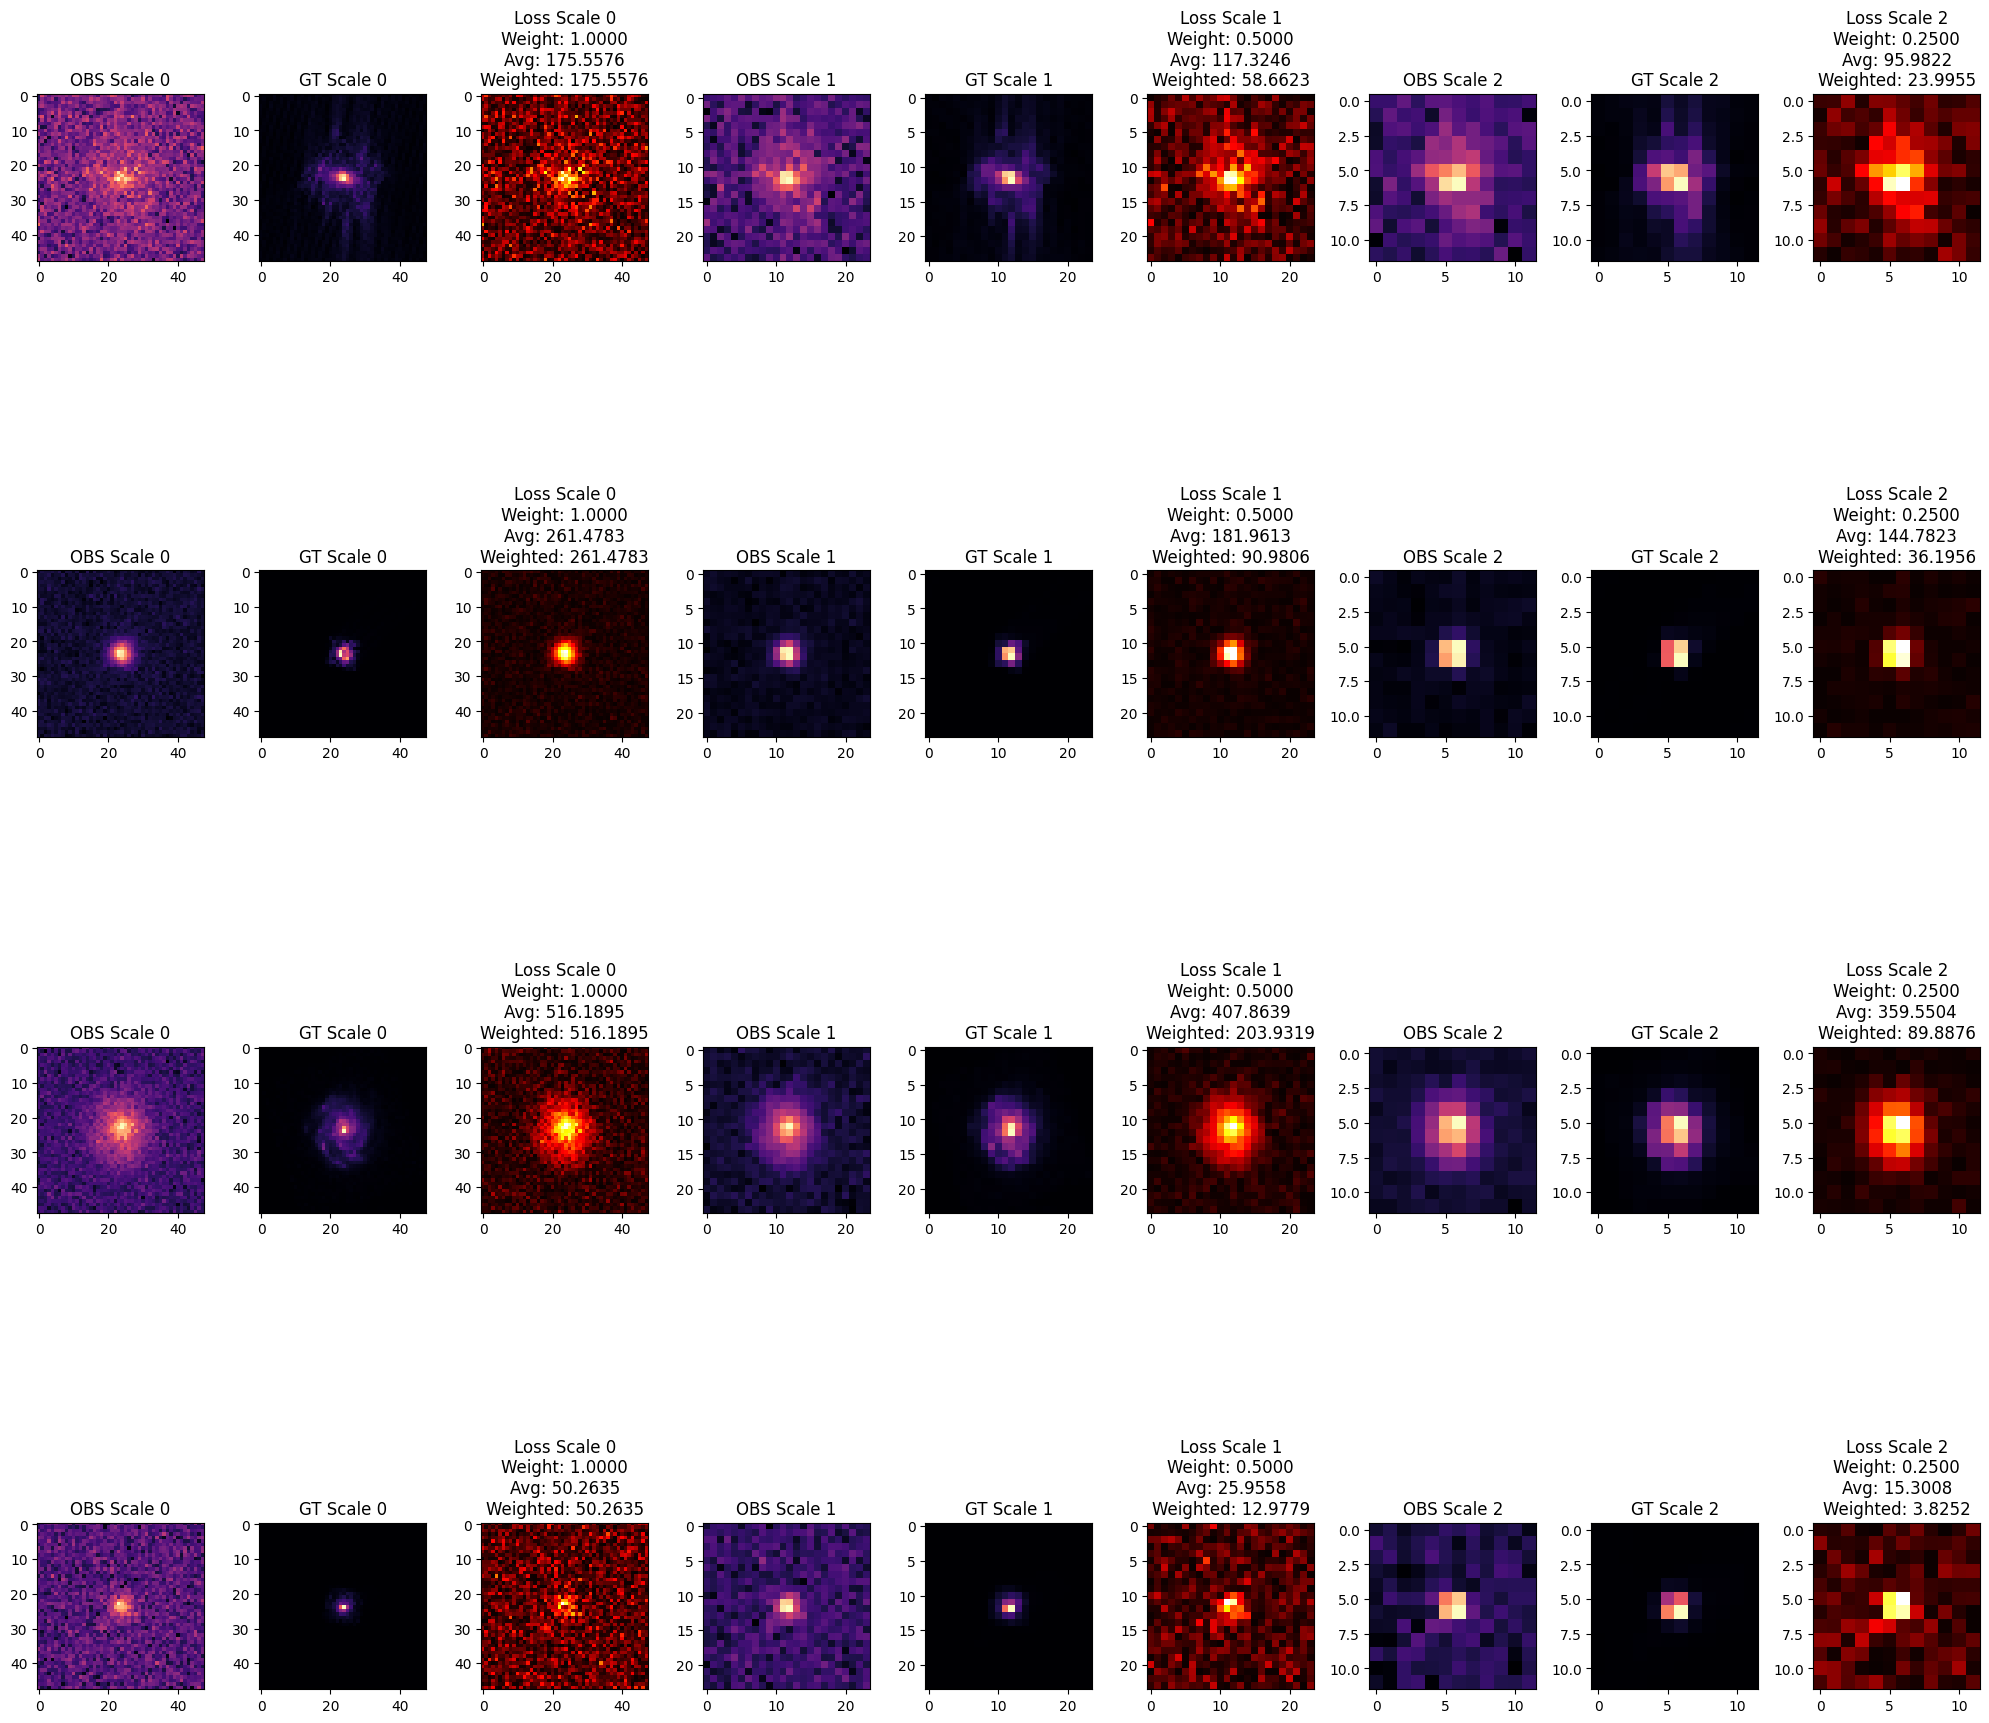

In [3]:
plot_multiscale_batch(obs_batch.unsqueeze(1).to(device),
                     alpha_batch.to(device),
                     gt_batch.unsqueeze(1).to(device),
                     example_batch_idxs)

## Training Results

During the model training with Multi-Scale MAE loss, there was rapid improvement in the first four epochs, followed by a steady decrease in loss until the model achieved its best performance at epoch 10. Throughout the training, the training and validation losses remained closely aligned, indicating good generalization with minimal overfitting.

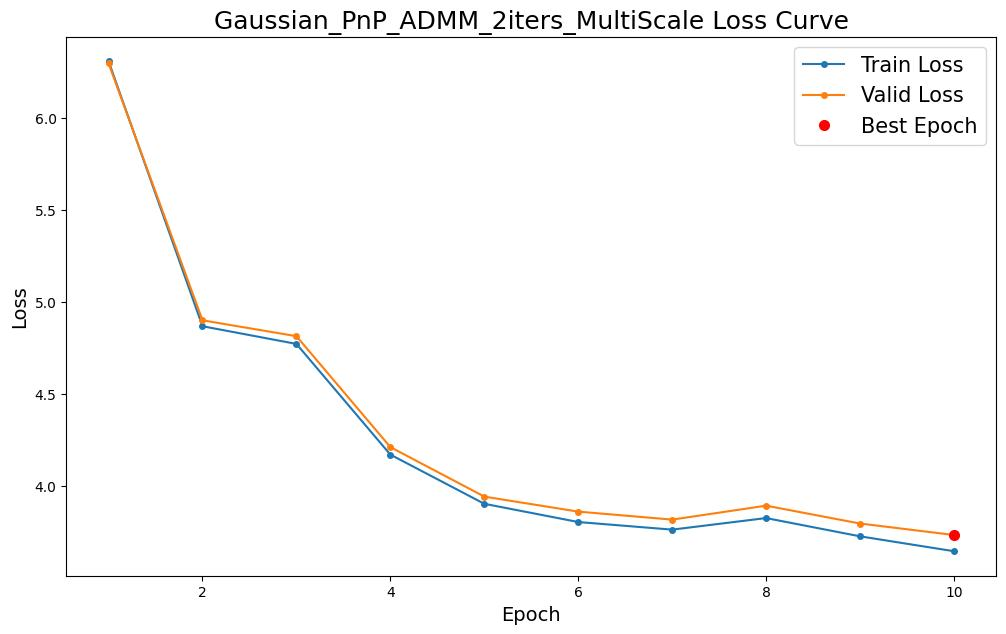

In [4]:
# load the trained model 
model_file = './saved_models_shape_loss/Gaussian_PnP_ADMM_2iters_MultiScale_10epochs.pth'

model = UnrolledADMMGaussian(n_iters=2, PnP=True, subnet=True)
model.to(device)
model.eval()
model.load_state_dict(torch.load(model_file, map_location=torch.device(device)))
print(f'Successfully loaded in {model_file}.')

Successfully loaded in ./saved_models_shape_loss/Gaussian_PnP_ADMM_2iters_MultiScale_10epochs.pth.


## Inference Results

The visualization below shows four sets of blurred, noisy images alongside their corresponding ground truth images and the output from the trained deconvolution model. The shear values between the deconvolved galaxy and the ground truth galaxy differ by no more than 0.134. The largest difference occurs with image 1, where the galaxy shape is more complex. This complexity may make it harder for the model to fully capture the intricate shape during deconvolution, potentially limiting its ability to produce an image with accurate shear. Overall, the model performs well, effectively deburring and removing noise from images with different signal-to-noise ratios (SNRs), and it appears to capture the relative shape accurately.

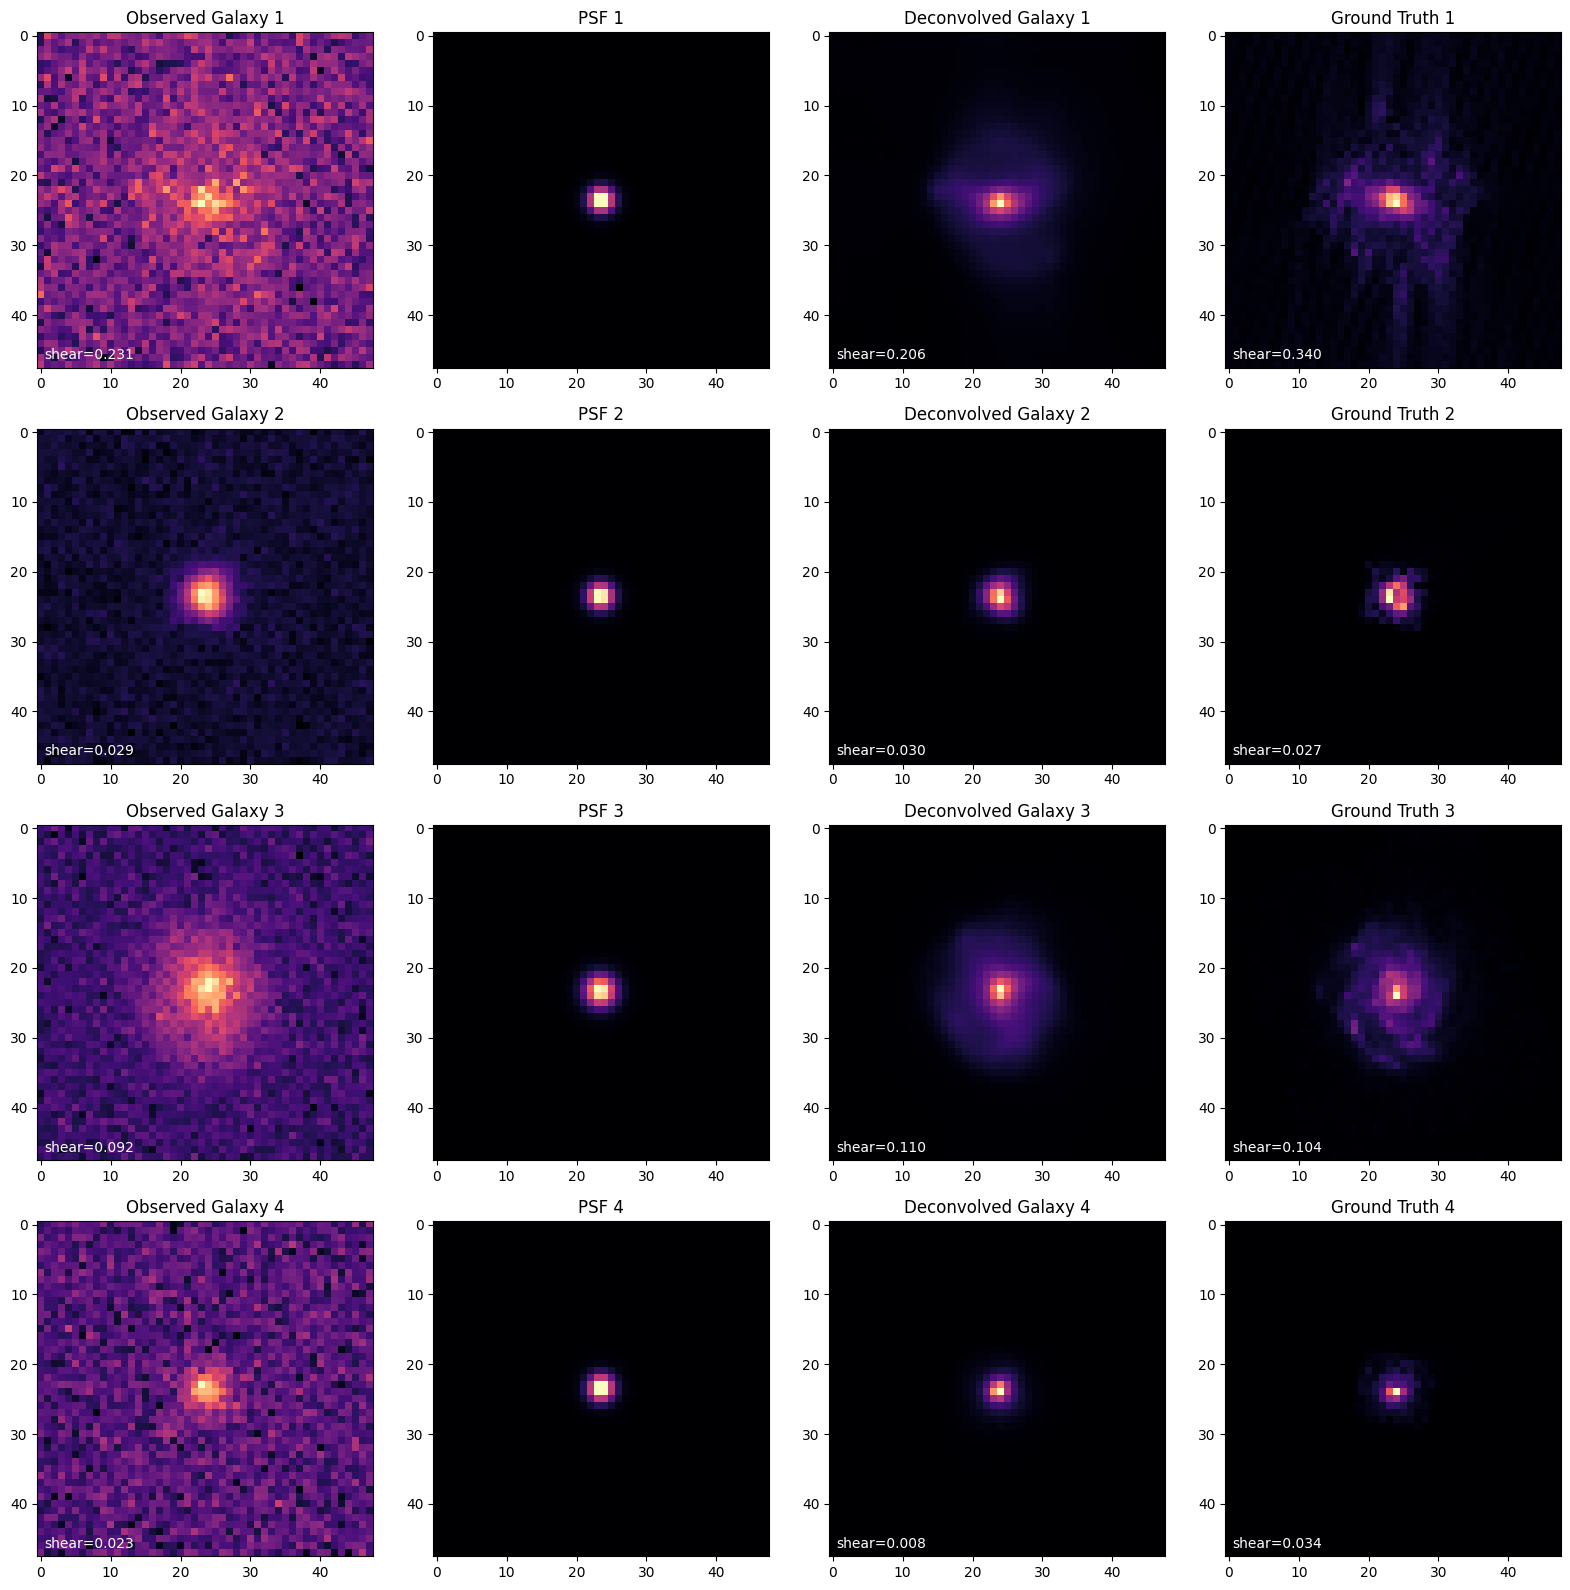

In [5]:
# run model on batch
psf_input = psf_batch.unsqueeze(1).to(device)  # Shape: [4, 1, 48, 48]
obs_input = obs_batch.unsqueeze(1).to(device)  # Shape: [4, 1, 48, 48]
alpha_input = alpha_batch.to(device)        # Shape: [4, 1, 1, 1]

with torch.no_grad():
    output_batch = model(obs_input, psf_input, alpha_input)

plot_inference_results(output_batch, alpha_batch, obs_batch, gt_batch, psf_batch)

plt.show()

# Best Ellipse Loss
---

A natural starting point for describing galaxy shape is to model it as an ellipse. By applying a mask to capture the galaxy's light distribution, converting relevant points to Cartesian coordinates, and employing [singular value decomposition (SVD)](https://en.wikipedia.org/wiki/Singular_value_decomposition), we can determine the ellipse equation coefficients. From the general conic equation $Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0$, we can extract the center coordinates $(x_0, y_0)$, semi-axis lengths $(a,b)$, and orientation angle $\theta$ through algebraic transformations. These parameters provide a mathematically robust foundation for quantifying galaxy shapes and subsequently measuring weak lensing shear with improved accuracy.

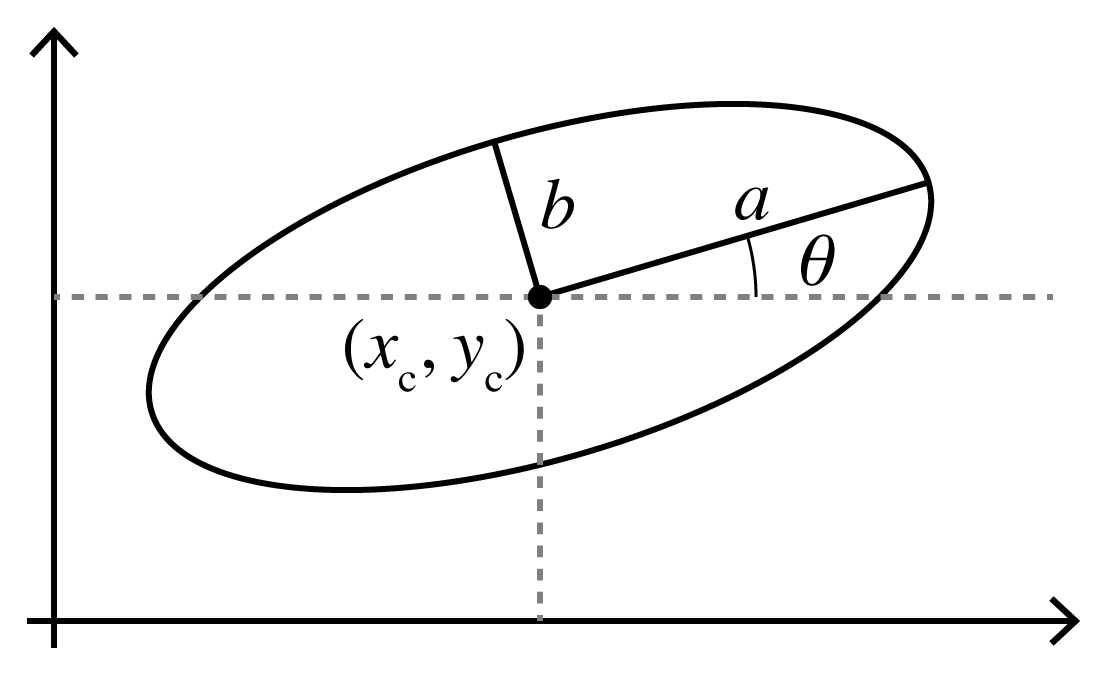
Image credit [4].

This method allows us to compare the predicted and ground truth ellipses, introducing a loss function that directly penalizes deviations in shape rather than individual pixel values. By shifting from pixel-wise loss to a global shape-based metric, this approach aims to improve shear estimation by focusing on structural accuracy rather than fine-grained pixel differences. To compute the loss between the model output and the ground truth ellipses, we fit ellipses to both in the same manner and compare their three main components:

1. Center Location Comparison: We calculate the Mean Squared Error (MSE) between the normalized center coordinates. The maximum semi-axis length from both ellipses is used as a normalization factor to ensure scale invariance.

2. Angle Comparison: The angles are converted into unit vectors, and their similarity is measured using cosine distance (1 - cosine similarity). This approach accounts for the periodic nature of angles.

3. Semi-Axis Length Comparison: We compute the normalized squared differences between the semi-axis lengths (a and b), using the maximum semi-axis length for normalization.

The final loss combines these three components into a single value, assigning equal weight to each. This results in a comprehensive metric that effectively captures ellipse similarity. However, to achieve this, we first need to develop a robust ellipse-fitting pipeline capable of fitting an ellipse to any galaxy image. Crucially, this pipeline must employ differentiable operations to ensure gradients can be tracked throughout the entire process, enabling proper weight updates during training. Below, I will outline my implementation.

## Galaxy Image Batch

Below is the batch of four ground truth galaxy images which we will fit ellipses to for demostration purposes.

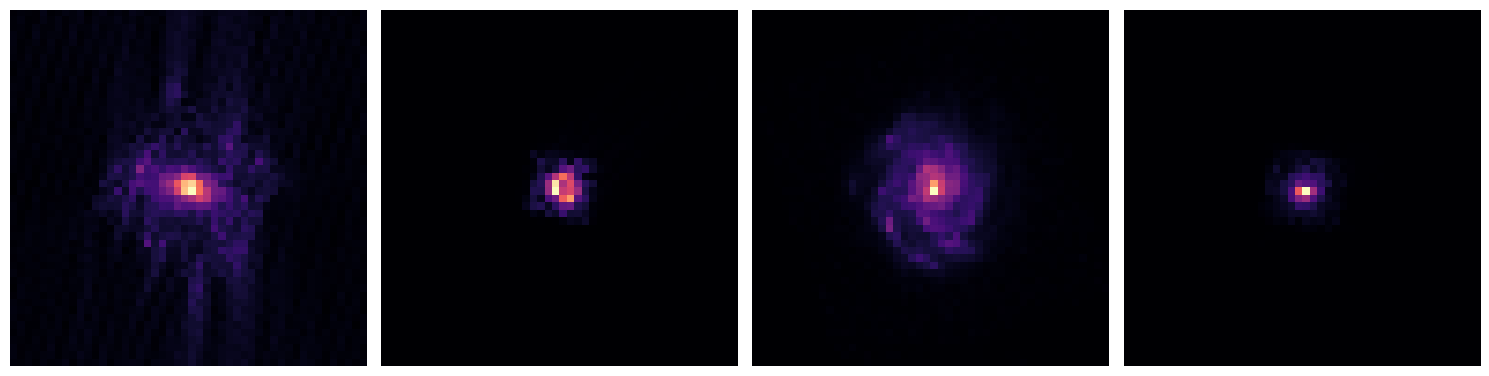

In [6]:
plot_batched_images(gt_batch)
plt.show()

# Masking

The first step in fitting an ellipse to a galaxy is creating a mask that captures the galaxy's elliptical shape. Since galaxies typically have brightest centers with brightness tapering toward edges, we apply a function that amplifies mid-range intensity values.
For an image with values between 0 and 1, the masking function is:

$M(x) = \frac{1}{\exp\left(\left(\frac{x - \text{peak\_pos}}{\text{sharpness}}\right)^2\right)}$

Where:

- peak_pos (typically 0.3-0.7) determines which intensity value receives maximum amplification

- sharpness controls the steepness of amplification drop-off around the peak value

Values close to peak_pos are strongly amplified, while values progressively farther away receive diminishing amplification, creating a mask that highlights the galaxy's structural boundaries. Below is a plot of the masking function with two different sets of hyperparameters.

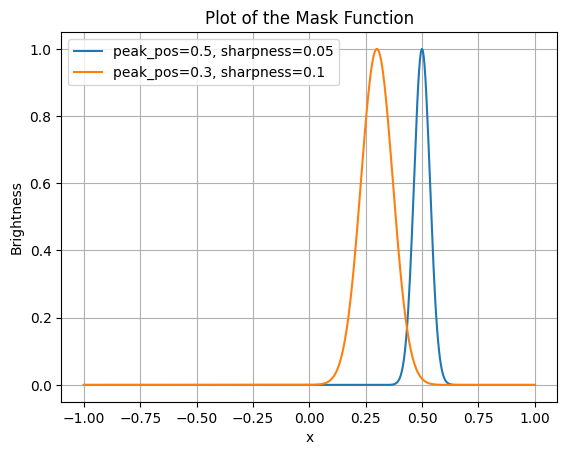

In [7]:
x_values = torch.linspace(-1, 1, 500)
y_values1 = mask_batched(x_values, peak_pos=0.5, sharpness=0.05)
y_values2 = mask_batched(x_values, peak_pos=0.3, sharpness=0.1)
x_values_np = x_values.numpy()
y_values_np1 = y_values1.numpy()
y_values_np2 = y_values2.numpy()

plt.plot(x_values_np, y_values_np1, label='peak_pos=0.5, sharpness=0.05')
plt.plot(x_values_np, y_values_np2, label='peak_pos=0.3, sharpness=0.1')
plt.xlabel('x')
plt.ylabel('Brightness')
plt.title('Plot of the Mask Function')
plt.grid(True)
plt.legend()
plt.show()

Below is the result of applying the orange masking function to each of the four images in the batch.

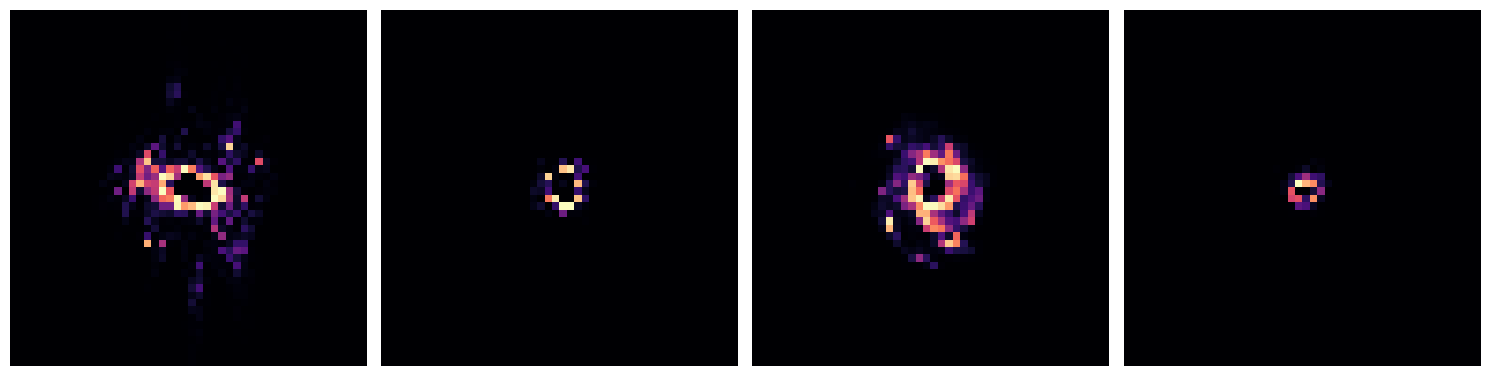

In [8]:
masked_image_batch = mask_batched(transform_tensor_batched(gt_batch), peak_pos=0.3, sharpness=0.1)
plot_batched_images(masked_image_batch)
plt.show()

## Masked Image to Cartesian Coordinate Points

Each pixel in the image mask is mapped to its corresponding (x, y) coordinate in 2D space. A weight is assigned to each point based on the mask value at that pixel location. Mapping all pixels is essential to maintain differentiability throughout the process.

Below are plots of the points with weights greater than 0.5 generated from each mask. The darkness of each point corresponds to its weight. Notably, only the second image contains a set of high-weight points that form a clear ellipse. In contrast, the first and third images include extraneous points, and the last image does not have enough points to define a complete ellipse.

/Users/michaelbertagna/git/Galaxy-Deconv/Galaxy-Deconv.env/lib/python3.11/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


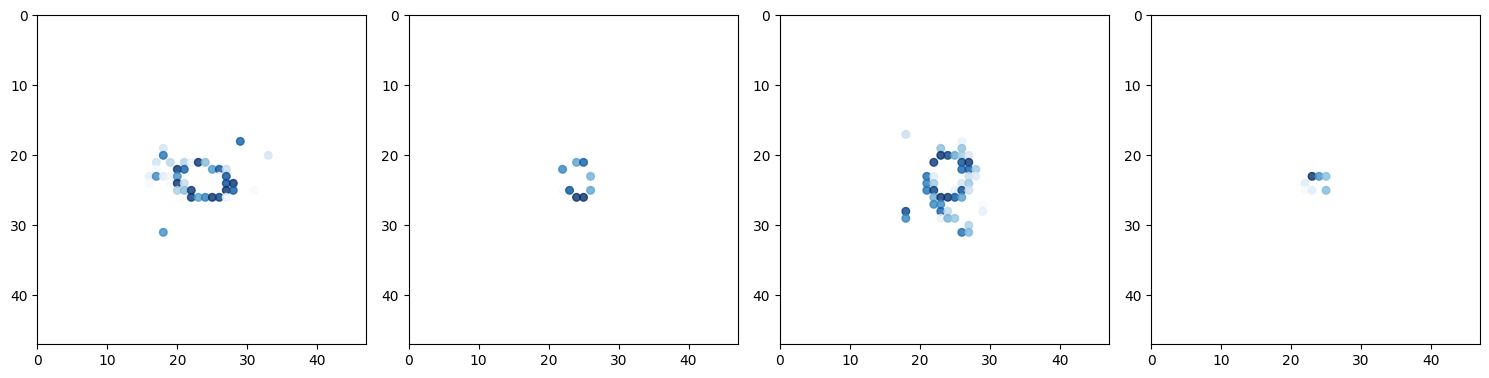

In [9]:
points, weights = mask_to_points_and_weights_batched(masked_image_batch)
plot_batched_points(points, weights, threshold=0.5)
plt.show()

## Fitting an Ellipse to Points with Singular value decomposition (SVD)

The equation of an [ellipse](https://en.wikipedia.org/wiki/Ellipse) which best represents the weighted set of points can be extracted with SVD by solving the conic section equation as an eigenvector problem. The weighted design matrix D is constructed using the point coordinates and their corresponding weights, with each row representing the terms of the conic equation for a single point, weighted by its mask value. SVD decomposes this matrix, and the last column of the V matrix (corresponding to the smallest singular value) provides the coefficients that minimize the algebraic distance between the points and the ellipse.
From the general conic equation $Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0$, we can extract the center coordinates $(x_0, y_0)$, semi-axis lengths $(a,b)$, and orientation angle $\theta$ through algebraic transformations with the equations:

Center: $x_0 = \frac{BE - 2CD}{4AC - B^2}$,
$y_0 = \frac{BD - 2AE}{4AC - B^2}$

Angle: $\theta = \frac{1}{2}\arctan\left(\frac{B}{A-C}\right)$

Semi-axes: $a = \sqrt{\frac{2(AE^2 + CD^2 - BDE + F(B^2 - 4AC))}{(B^2 - 4AC)(\sqrt{(A-C)^2 + B^2} - (A+C))}}$,
$b = \sqrt{\frac{2(AE^2 + CD^2 - BDE + F(B^2 - 4AC))}{(B^2 - 4AC)(-\sqrt{(A-C)^2 + B^2} - (A+C))}}$

As we observed after converting the mask to coordinate points, not every masking approach works optimally for every galaxy image. To address this variability, we implement a systematic search across different mask hyperparameters, particularly testing various peak position and sharpness values that amplify different intensity ranges in the image. The quality of each ellipse fit is evaluated using a normalized metric (ranging from 0 to 1) that quantifies how well the ellipse captures the galaxy's structure. This metric calculates the ratio between the weighted brightness inside the ellipse versus outside with higher values indicating better fits. The weighting scheme gives additional importance to pixels closer to the center, which aligns with galaxy morphology where central regions typically have greater significance. For each galaxy image, we select the best-fitting ellipse based on the highest metric score. We then apply these optimal ellipse fitting parameters to the model-generated galaxy image, tracking gradients only for the best-fitting parameters. This ensures a consistent basis for comparing predicted and ground truth galaxy shapes.

Below is an example where we fit ellipses using three different peak position parameters for masking a batch of ground truth images. Notice that better-fitting ellipses correspond to higher ellipse fit metric values.

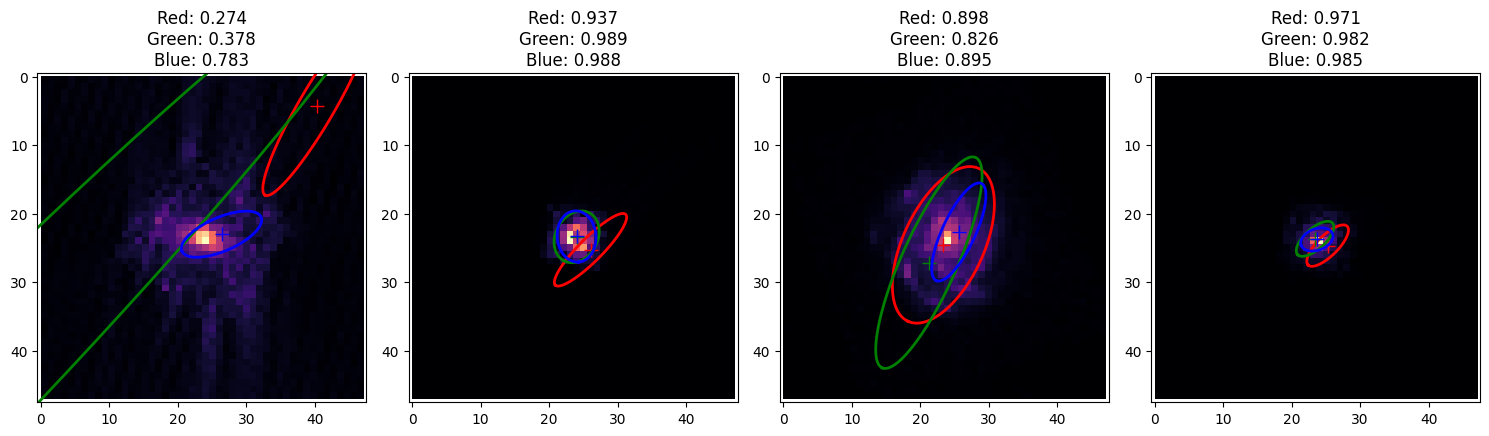

In [10]:
peak_positions=[0.25, 0.3, 0.35]

params_sets = []
ellipse_fit_metrics = []

for peak_pos in peak_positions:
    param_set, _ = ellipse_params_batched(transform_tensor_batched(gt_batch), peak_pos=peak_pos)
    fit_metric = ellipse_fit_metric(gt_batch, param_set)
    params_sets.append(param_set)
    ellipse_fit_metrics.append(fit_metric)

plot_batch_with_ellipses(gt_batch, params_sets, ellipse_fit_metrics=ellipse_fit_metrics)
plt.show()

## Training Results

During model training with the Best Ellipse loss in its current form, both training and validation loss values fluctuate dramatically in magnitude. Further refinements to the loss function are needed to stabilize these values and ensure invariance to changes in ellipse fitting and ellipse parameters.

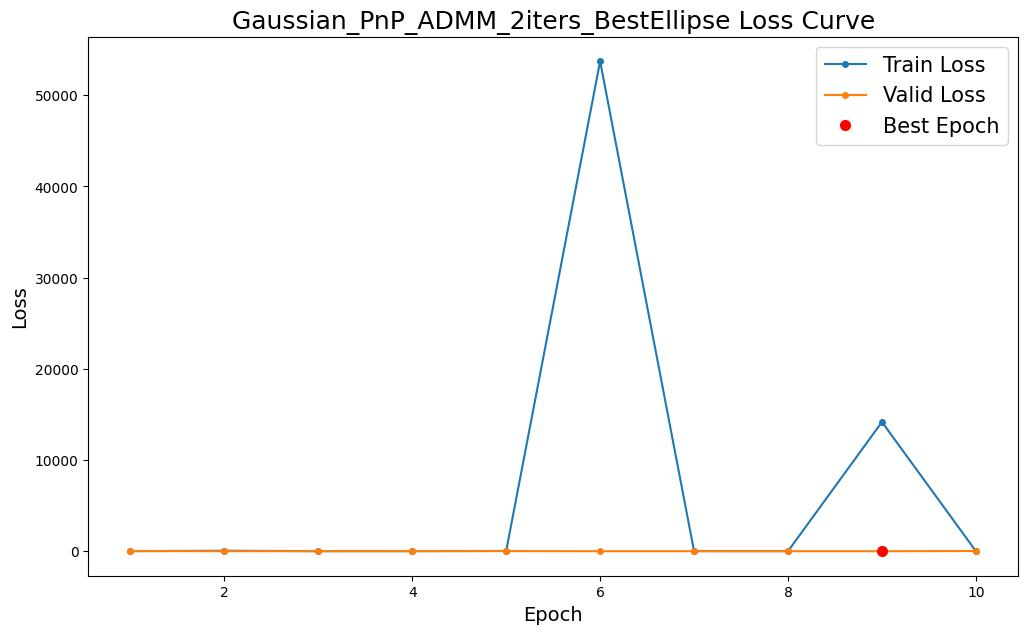

In [11]:
# load the trained model
model_file = './example_models/Gaussian_PnP_ADMM_2iters_BestEllipse_10epochs.pth'

model = UnrolledADMMGaussian(n_iters=2, PnP=True, subnet=True)
model.to(device)
model.eval()
model.load_state_dict(torch.load(model_file, map_location=torch.device(device)))
print(f'Successfully loaded in {model_file}.')

Successfully loaded in ./example_models/Gaussian_PnP_ADMM_2iters_BestEllipse_10epochs.pth.


## Inference Results

The visualization below presents four sets of blurred, noisy images alongside their corresponding ground truth images and the output from the trained deconvolution model. Notably, the shear values for the deconvolved galaxies are around 0.9, and an unusual grid-like brightness pattern appears in the bottom right corner of each. However, the shear values differ between deconvolved galaxies the inferernce image are different. Overall, the Best Ellipse loss function remains a work in progress and is not yet a viable option for model training.

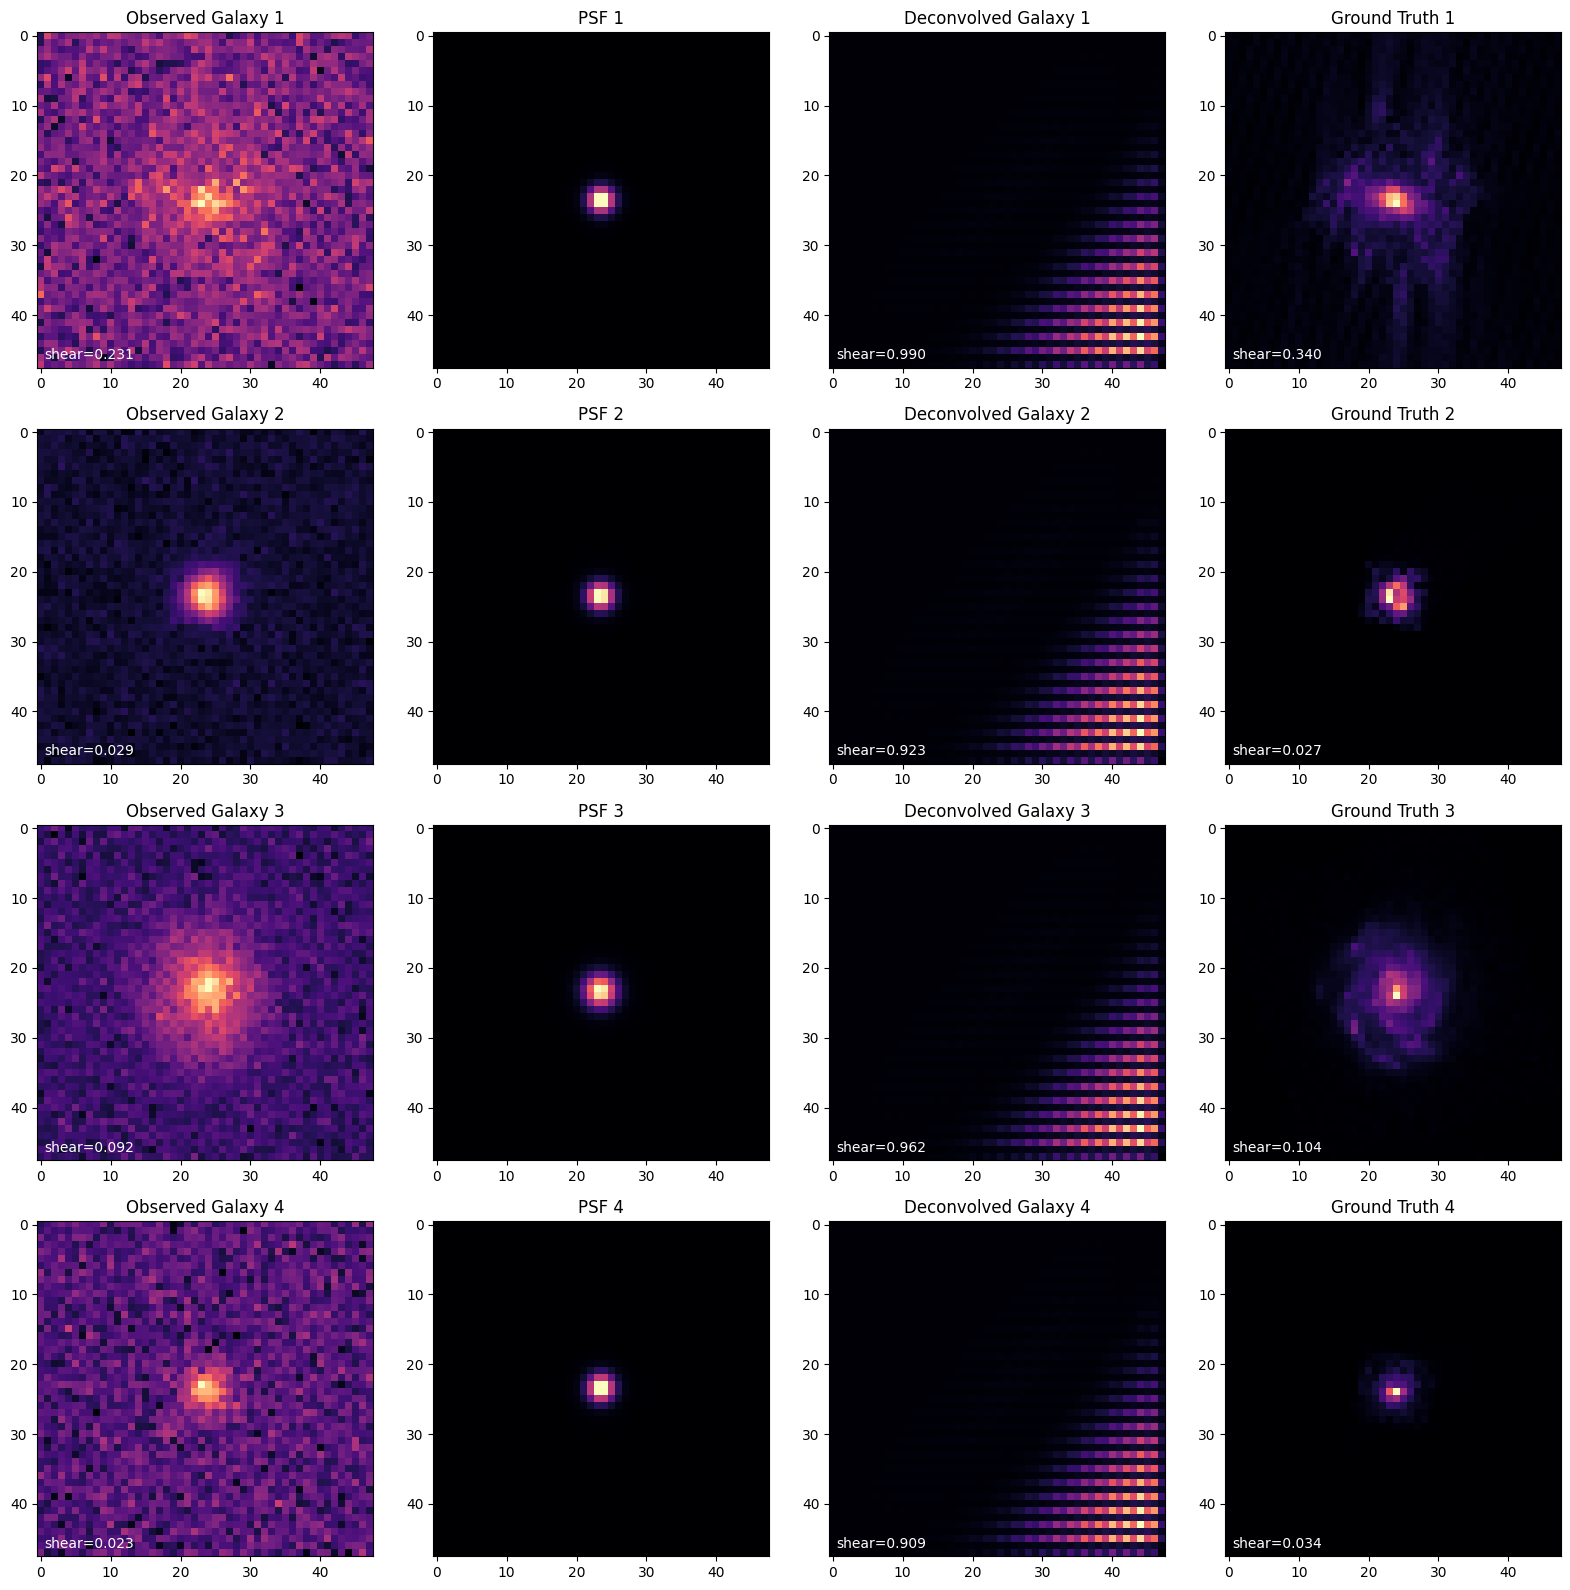

In [12]:
# run model on batch
psf_input = psf_batch.unsqueeze(1).to(device)  # Shape: [4, 1, 48, 48]
obs_input = obs_batch.unsqueeze(1).to(device)  # Shape: [4, 1, 48, 48]
alpha_input = alpha_batch.to(device)        # Shape: [4, 1, 1, 1]

with torch.no_grad():
    output_batch = model(obs_input, psf_input, alpha_input)

plot_inference_results(output_batch, alpha_batch, obs_batch, gt_batch, psf_batch)

plt.show()

# Central Moment Loss
---

[Image moments](https://en.wikipedia.org/wiki/Image_moment) characterize the spatial distribution of pixel intensities. For a 2D image with intensity function $I(x,y)$, the raw moment of order $(p+q)$ is:

$m_{pq} = \sum_{x}\sum_{y} x^p y^qI(x,y)$

The zeroth-order moment ($m_{00}$​) gives the total intensity.

First-order moments normalized by $m_{00}$​ provide the centroid $(x_c, y_c)$:

$x_c = \frac{m_{10}}{m_{00}}, \quad y_c = \frac{m_{01}}{m_{00}}$

Central moments remove dependence on position:

$\mu_{pq} = \sum_{x}\sum_{y} (x - x_c)^p (y - y_c)^q I(x,y)$

Second-order central moments $\mu_{20}$, $\mu_{11}$​, and $\mu_{02}$​ form a covariance matrix that yields the major/minor semi-axis lengths and orientation angle of the ellipse, while the center point is determined by the first-order moments normalized by the total intensity. However, an ellipse can only be fit reliably if the image contains a single dominant object because moments are computed globally for an image.

Higher-order moments capture more complex shape characteristics, such as third-order moments which measure asymmetry and skewness. However, higher order moments are known to be more sensitive to noise, as they capture increasing complex patterns.

In my implementation of Central Moment loss, I compared moment values from the first to the third order using Mean Squared Error (MSE) between the ground truth and model output images. I assigned equal weight to the first-order, second-order, and third-order loss components.

Below is a batch of four ground truth galaxy images where up to the second-order moments have been computed to extract and plot ellipses that describe the galaxy in each image.

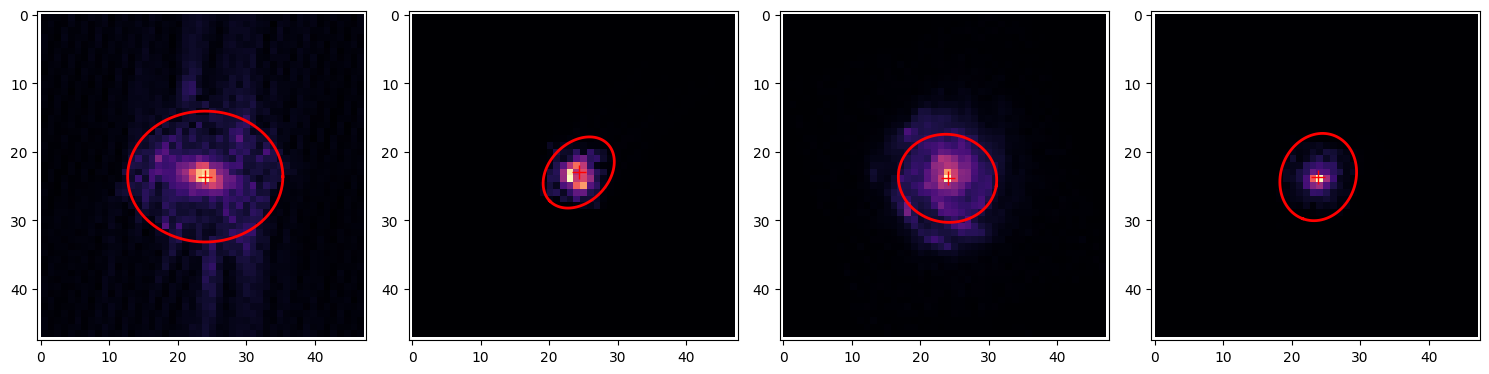

In [13]:
params = ellipse_params_from_moments(gt_batch)

fig, axes = plot_batch_with_ellipses(gt_batch, [params])
plt.show()

## Training Results

During model training with Central Moment loss, the loss decreased rapidly during the first two epochs, then steadily declined until the fifth epoch. At that point, the loss temporarily increased before recovering by epoch nine. The model reached its minimum loss after epoch 10. Throughout training, the training and validation losses remained closely aligned, indicating good generalization with minimal overfitting.

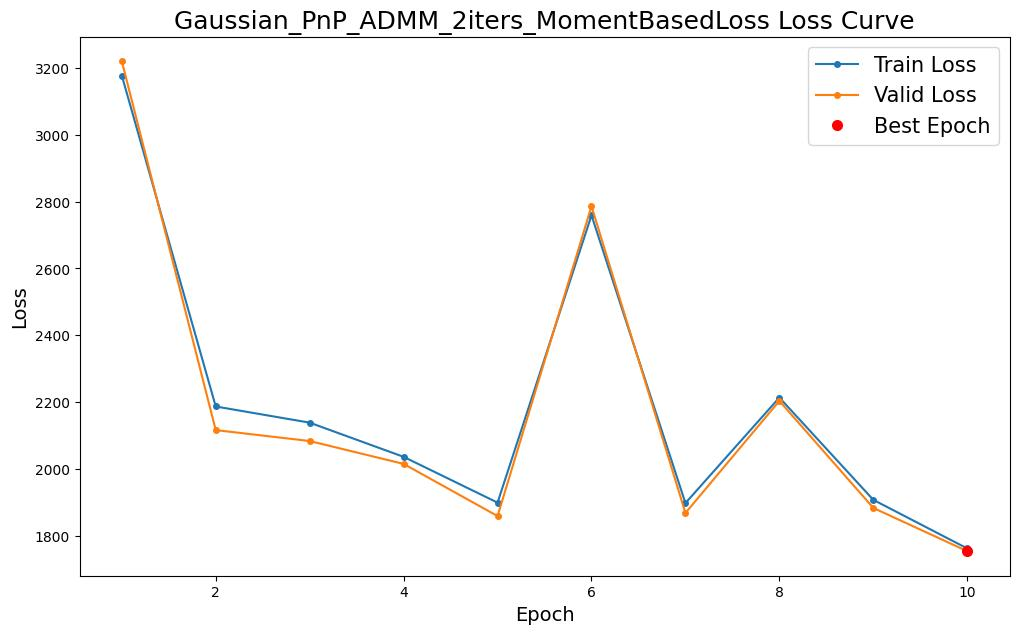

In [14]:
# load the trained model
model_file = './example_models/Gaussian_PnP_ADMM_2iters_MomentBasedLoss_10epochs.pth'

model = UnrolledADMMGaussian(n_iters=2, PnP=True, subnet=True)
model.to(device)
model.eval()
model.load_state_dict(torch.load(model_file, map_location=torch.device(device)))
print(f'Successfully loaded in {model_file}.')

Successfully loaded in ./example_models/Gaussian_PnP_ADMM_2iters_MomentBasedLoss_10epochs.pth.


## Inference Results

The visualization below shows four sets of blurred, noisy images alongside their corresponding ground truth images and the output from the trained deconvolution model. While the deconvolved galaxy images resemble the general shape of the ground truth galaxies, the brightness patterns do not match and a strange grid-like brightness pattern appears. Some shear values are close to the ground truth. However, the first image has a complex shape, and the shear value in the deconvolved galaxy deviates by 0.273. This difference is significantly larger than the difference observed with the Multi-Scale loss result. This suggests that up to third-order moments may not fully capture the galaxy’s shape, leading to inaccurate shear values. Further testing is needed to determine the optimal combination of lower and higher-order moments and the appropriate weight to assign each in the loss function.

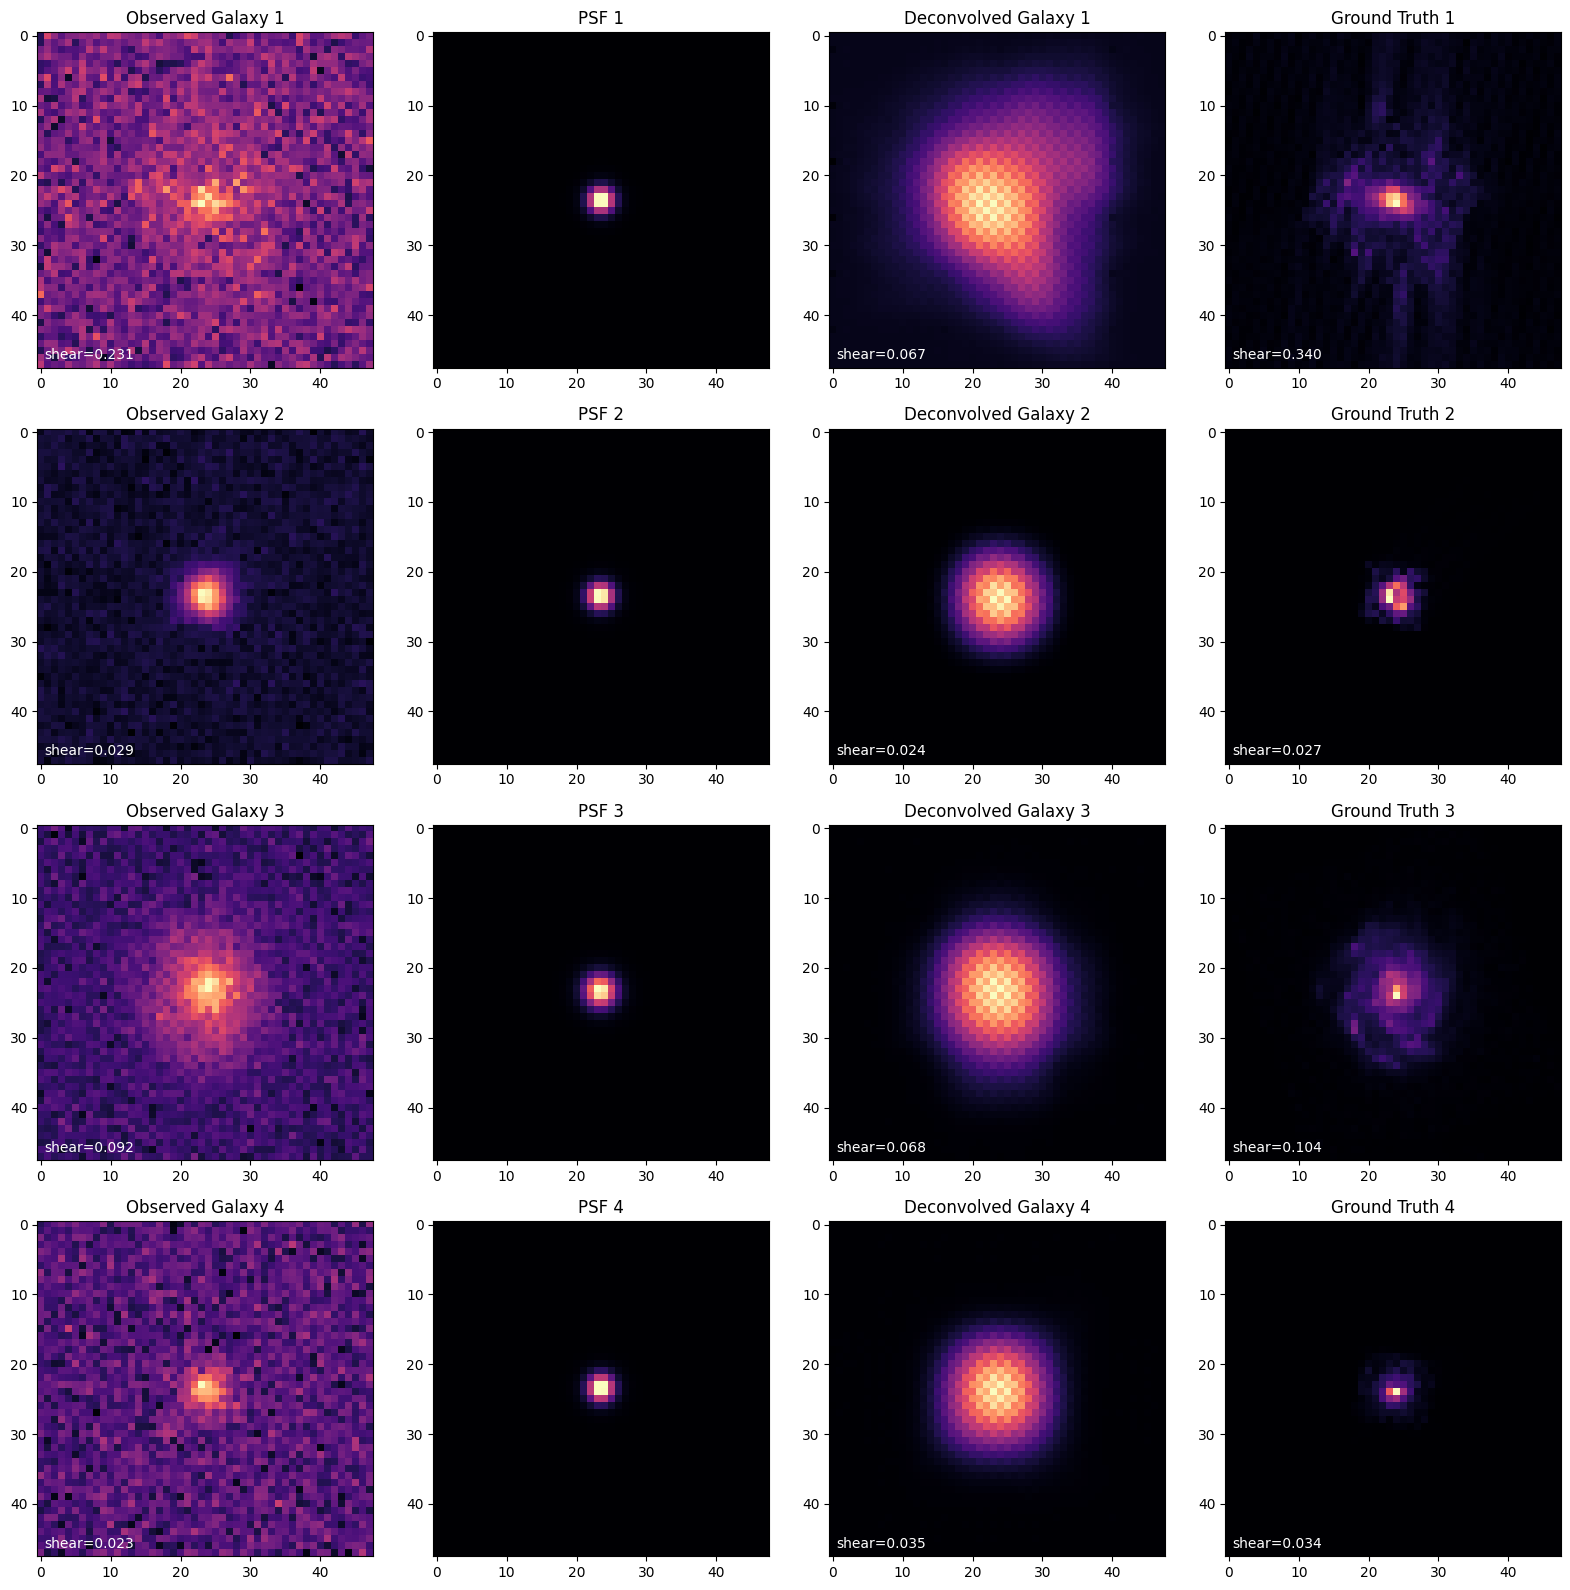

In [15]:
# run model on batch
psf_input = psf_batch.unsqueeze(1).to(device)  # Shape: [4, 1, 48, 48]
obs_input = obs_batch.unsqueeze(1).to(device)  # Shape: [4, 1, 48, 48]
alpha_input = alpha_batch.to(device)        # Shape: [4, 1, 1, 1]

with torch.no_grad():
    output_batch = model(obs_input, psf_input, alpha_input)

plot_inference_results(output_batch, alpha_batch, obs_batch, gt_batch, psf_batch)

plt.show()

# Shapelet Moment Loss
---

Shapelet moments provide a mathematical framework for decomposing galaxy shapes using special basis functions derived from Gaussian-weighted [Laguerre polynomials](https://en.wikipedia.org/wiki/Laguerre_polynomials). These basis functions form an orthonormal set that describes the intensity distribution of a galaxy image in terms of increasingly complex shape components. The process involves determining the galaxy’s centroid and characteristic scale radius, normalizing pixel coordinates by this scale, projecting the image onto the shapelet basis functions, and computing the corresponding shapelet coefficients.

Second-order shapelet moments ($S_2$) primarily capture a galaxy’s ellipticity, indicating whether it is elongated along a particular axis. Fourth-order moments ($S_4$) characterize higher-order distortions, such as “boxiness” or “diskiness,” which describe deviations from a purely elliptical shape. These shapelet-based measurements are particularly useful in weak lensing studies, as they provide a compact, noise-robust representation of galaxy shapes and respond predictably to gravitational shear [3].

In my implementation of Shapelet Moment loss, I compared moment values from the second-order shapelet moments ($S_2$) and fourth-order moments ($S_4$) using Mean Squared Error (MSE) between the ground truth and model output images. I assigned equal weight to the each of the loss components.

Below is a plot of the Laguerre shapelet basis functions for orders 2 and 4.

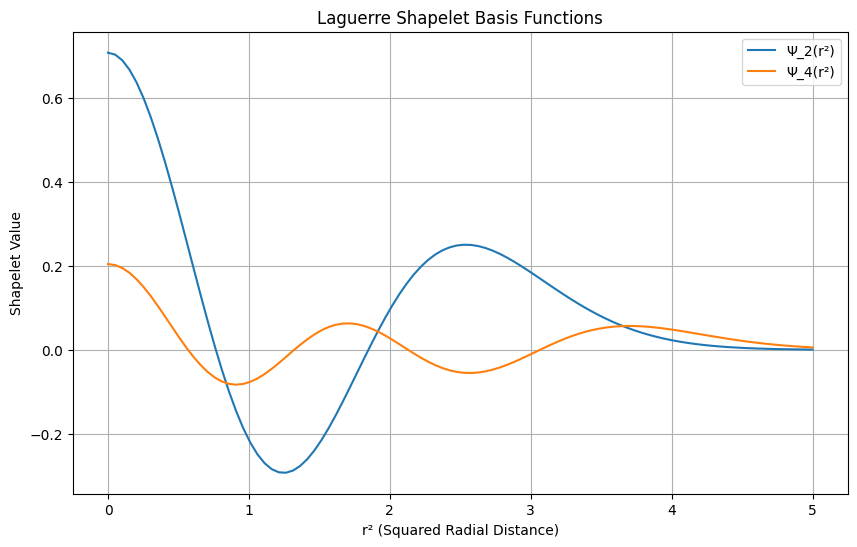

In [16]:
visualize_shapelet_basis(orders=[2, 4])

## Training Results

During model training with Shapelet Moment loss, the loss initially decreased from epochs 1 to 3, reaching a local minimum. This was followed by fluctuations with large loss peaks at epochs 4 and 7 where both training and validation losses spiked dramatically. After this spike, losses declined steadily through epochs 8-10. Throughout training, validation loss consistently tracked higher than training loss with similar patterns, suggesting the model had generalization challenges.

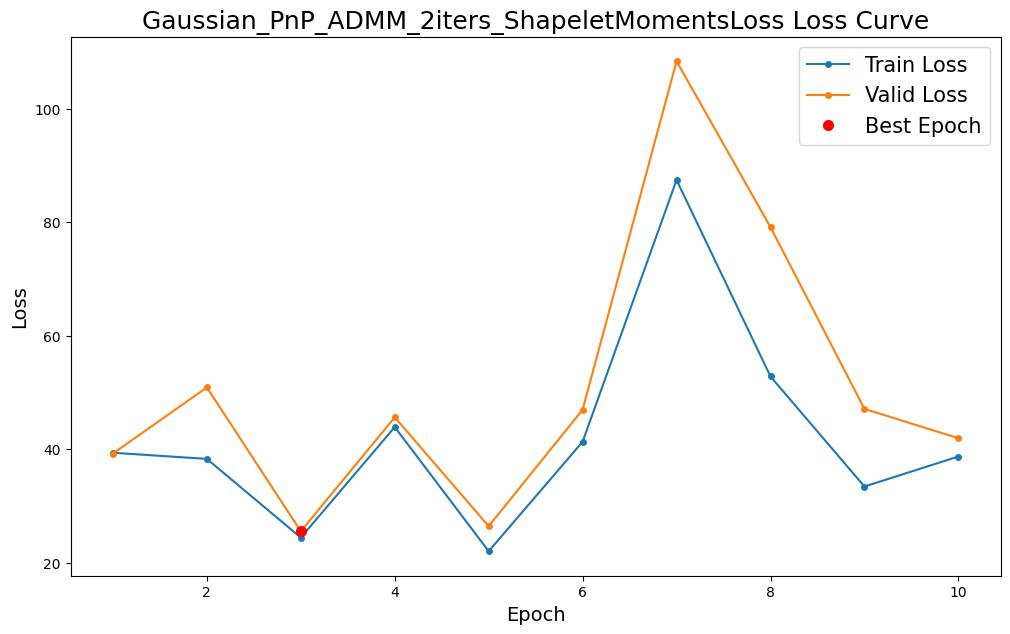

In [17]:
# load the trained model
model_file = './example_models/Gaussian_PnP_ADMM_2iters_ShapeletMomentsLoss_10epochs.pth'

model = UnrolledADMMGaussian(n_iters=2, PnP=True, subnet=True)
model.to(device)
model.eval()
model.load_state_dict(torch.load(model_file, map_location=torch.device(device)))
print(f'Successfully loaded in {model_file}.')

Successfully loaded in ./example_models/Gaussian_PnP_ADMM_2iters_ShapeletMomentsLoss_10epochs.pth.


## Inference Results

The visualization below shows four sets of blurred, noisy images alongside their corresponding ground truth images and the output from the trained deconvolution model. While the deconvolved galaxy images generally match the shape and brightness distribution of the ground truth galaxies, an unusual grid-like pattern is present. Although the shear values fall within a reasonable range, they do not closely match the ground truth values, with the largest deviation reaching 0.169 in the first image. The loss function likely requires further tuning to accurately reproduce galaxies with correct shear. Potential improvements include adjusting the weights of the second- and fourth-order moments or incorporating central moments into the loss function to better capture the galaxy’s overall shape.

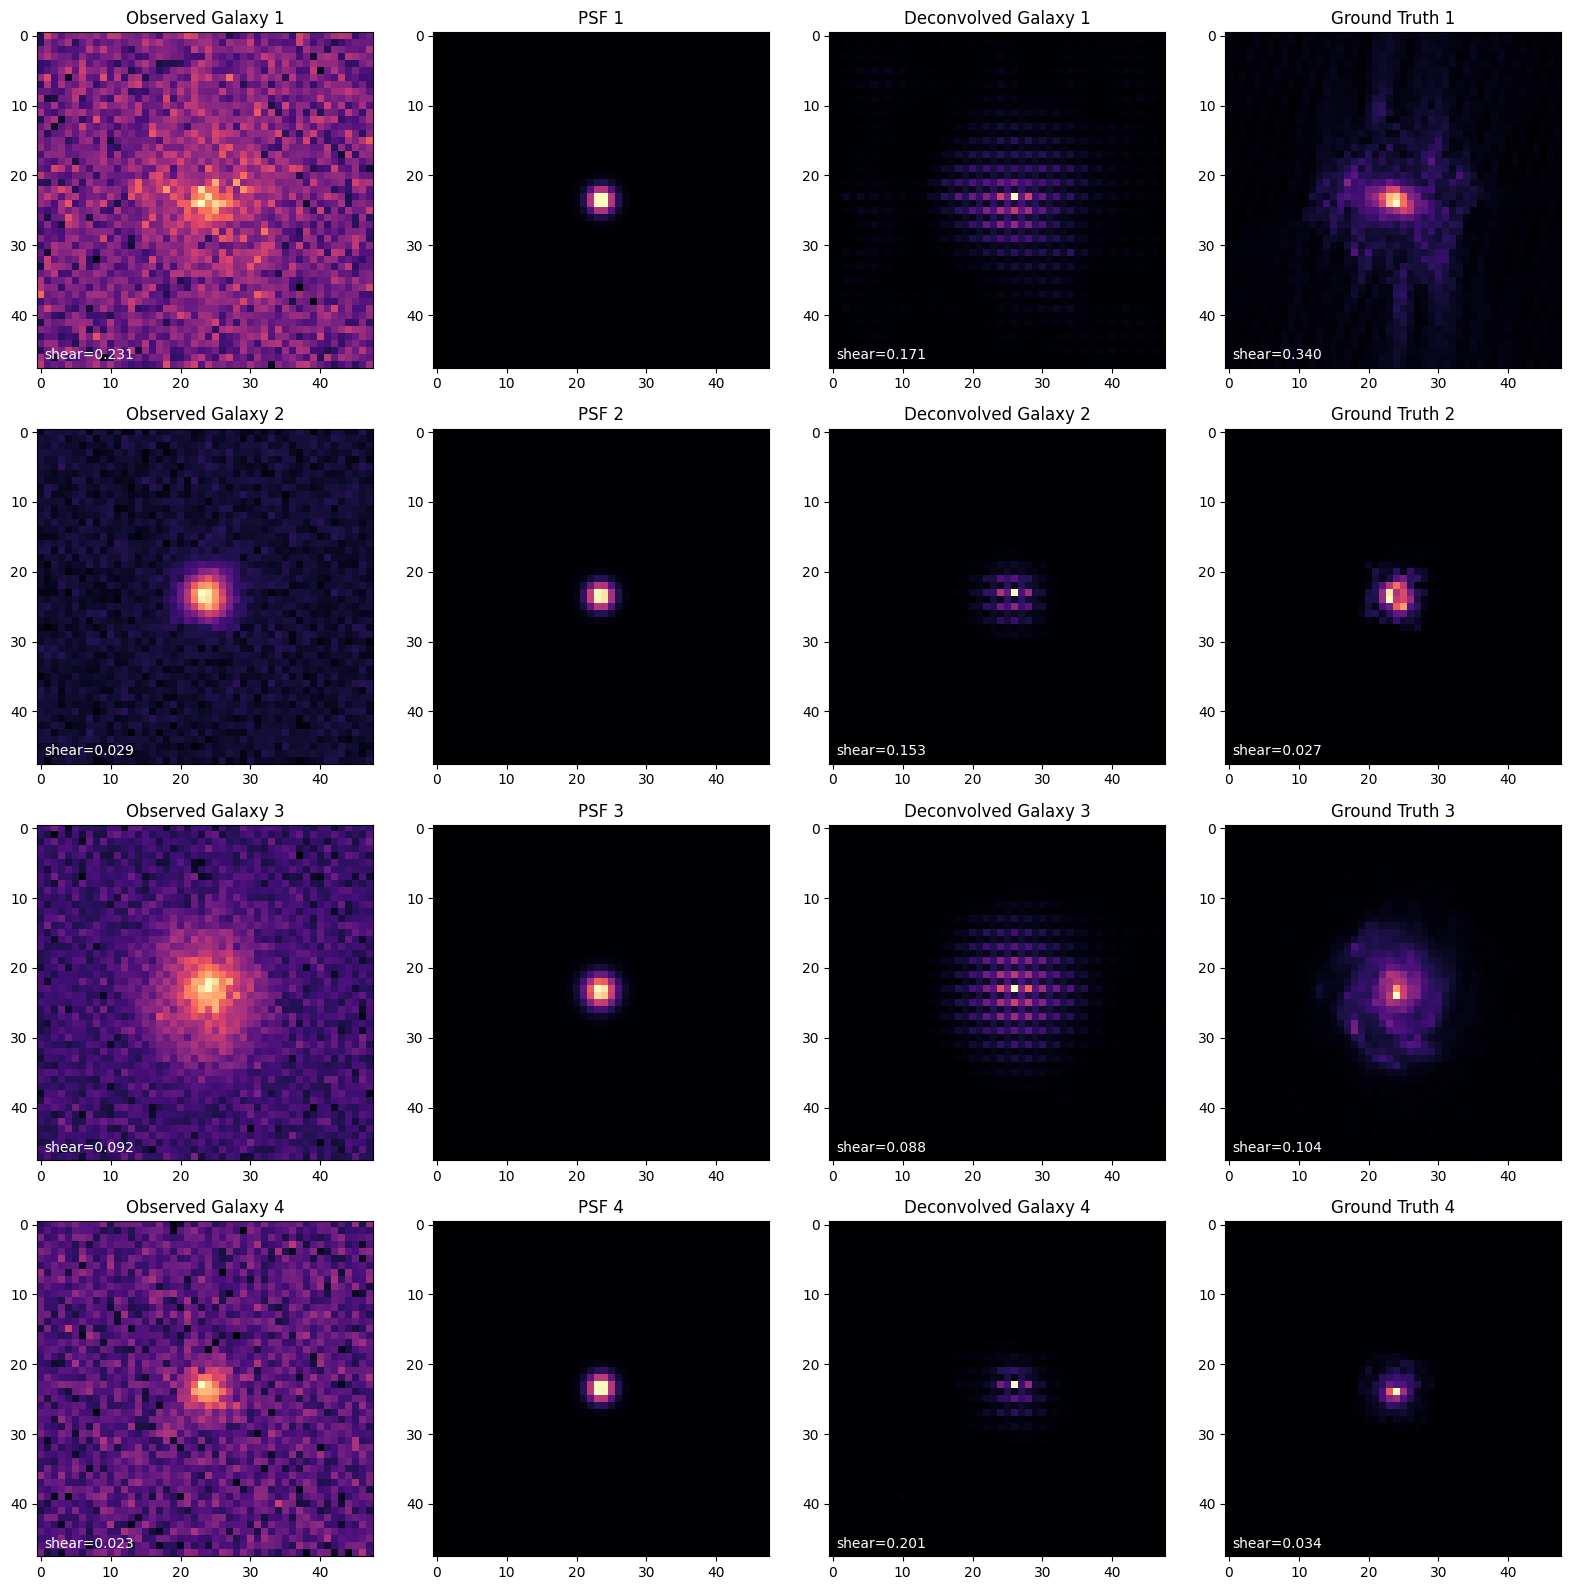

In [18]:
# run model on batch
psf_input = psf_batch.unsqueeze(1).to(device)  # Shape: [4, 1, 48, 48]
obs_input = obs_batch.unsqueeze(1).to(device)  # Shape: [4, 1, 48, 48]
alpha_input = alpha_batch.to(device)        # Shape: [4, 1, 1, 1]

with torch.no_grad():
    output_batch = model(obs_input, psf_input, alpha_input)

plot_inference_results(output_batch, alpha_batch, obs_batch, gt_batch, psf_batch)

plt.show()

# Conclusions and Future Directions
---

This project explored several shape-based loss functions for improving shear estimation in galaxy image deconvolution.
- Multi-Scale MAE Loss served as the baseline, extending standard MAE by incorporating loss across multiple image resolutions. This approach effectively preserved structural features and stabilized training.
- Best Ellipse Loss showed promising initial results but produced inconsistencies in shear values and introduced an unusual grid-like brightness pattern, indicating that further refinement is needed.
- Central Moment Loss captured general galaxy shapes, but third-order moments alone were insufficient for accurate shear estimation. Some images exhibited large shear deviations, suggesting the need for additional moment orders or weight adjustments.
- Shapelet Moment Loss maintained reasonable shear values but struggled to match ground truth shear closely. While shapelet moments provided a structured representation of galaxy shapes, tuning the weighting of different moment orders remains an area for improvement.

There are several promising directions for further refining these loss functions, including optimizing the choice of ellipse parameters and moments, adjusting normalization to improve invariance, and fine-tuning training hyperparameters. Once a loss function shows strong performance, a comprehensive comparison with the baseline Multi-Scale loss on shear estimation will be necessary.

Additionally, an alternative approach could involve training a small CNN to estimate shear using FPFS [3] and comparing its predictions to ground truth values. Future work may also explore estimating shear for multiple galaxies within an image and incorporating error bars for more robust uncertainty estimation.

By continuing to refine these methods, we move closer to a loss function that accurately preserves galaxy morphology and improves shear estimation in deconvolution models.

# Bibliography
---

[1] T. Li and E. Alexander, “Galaxy image deconvolution for weak gravitational lensing with unrolled plug-and-play ADMM,” Monthly Notices of the Royal Astronomical Society: Letters, vol. 522, no. 1, pp. L31–L35, Mar. 2023, doi: 10.1093/mnrasl/slad032.

[2] “Home Page,” COSMOS. Accessed: Mar. 17, 2025. [Online]. Available: https://cosmos.astro.caltech.edu/

[3] A. Park, X. Li, and R. Mandelbaum, “Accurate shear estimation with fourth-order moments,” Monthly Notices of the Royal Astronomical Society, vol. 537, no. 1, pp. 507–519, Jan. 2025, doi: 10.1093/mnras/staf053.

[4] “Unprojecting text with ellipses,” Needlessly complex. Accessed: Mar. 17, 2025. [Online]. Available: https://mzucker.github.io/2016/10/11/unprojecting-text-with-ellipses.html

# QUEST TUTORIAL

environment setup

most useful commands

CPU jobs

GPU jobs